In [11]:
# Install libraries one at a time to avoid conflicts
!pip install yfinance --quiet
!pip install pandas numpy --quiet
!pip install matplotlib seaborn --quiet
!pip install scipy --quiet
!pip install scikit-learn --quiet
!pip install statsmodels --quiet

print("All libraries installed successfully!")

All libraries installed successfully!


In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import StandardScaler
from statsmodels.regression.linear_model import WLS
from statsmodels.tools import add_constant
from scipy import stats
from datetime import datetime

warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0A1628'
plt.rcParams['axes.facecolor']   = '#0A1628'
plt.rcParams['axes.edgecolor']   = '#1E3A5F'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#1E3A5F'
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'monospace'

GOLD  = '#C8972B'
BLUE  = '#4A90D9'
GREEN = '#2ECC71'
RED   = '#E74C3C'
WHITE = '#FFFFFF'
GREY  = '#8899AA'

START_DATE = "2018-01-01"
END_DATE   = datetime.today().strftime("%Y-%m-%d")

# ASX 200 stocks with sector and fundamental data
STOCK_DATA = {
    'CBA.AX' : {'sector': 'Financials',             'beta': 0.95, 'book_price': 0.357, 'roe': 0.138, 'mktcap': 213e9},
    'NAB.AX' : {'sector': 'Financials',             'beta': 1.00, 'book_price': 0.556, 'roe': 0.118, 'mktcap': 92e9},
    'WBC.AX' : {'sector': 'Financials',             'beta': 1.02, 'book_price': 0.588, 'roe': 0.102, 'mktcap': 85e9},
    'ANZ.AX' : {'sector': 'Financials',             'beta': 1.05, 'book_price': 0.625, 'roe': 0.108, 'mktcap': 78e9},
    'MQG.AX' : {'sector': 'Financials',             'beta': 1.20, 'book_price': 0.417, 'roe': 0.148, 'mktcap': 68e9},
    'BHP.AX' : {'sector': 'Materials',              'beta': 1.10, 'book_price': 0.476, 'roe': 0.210, 'mktcap': 212e9},
    'RIO.AX' : {'sector': 'Materials',              'beta': 1.05, 'book_price': 0.526, 'roe': 0.195, 'mktcap': 190e9},
    'FMG.AX' : {'sector': 'Materials',              'beta': 1.25, 'book_price': 0.455, 'roe': 0.285, 'mktcap': 55e9},
    'S32.AX' : {'sector': 'Materials',              'beta': 1.15, 'book_price': 0.500, 'roe': 0.125, 'mktcap': 28e9},
    'MIN.AX' : {'sector': 'Materials',              'beta': 1.30, 'book_price': 0.385, 'roe': 0.165, 'mktcap': 18e9},
    'CSL.AX' : {'sector': 'Healthcare',             'beta': 0.72, 'book_price': 0.105, 'roe': 0.245, 'mktcap': 138e9},
    'RMD.AX' : {'sector': 'Healthcare',             'beta': 0.68, 'book_price': 0.139, 'roe': 0.228, 'mktcap': 56e9},
    'COH.AX' : {'sector': 'Healthcare',             'beta': 0.75, 'book_price': 0.125, 'roe': 0.215, 'mktcap': 18e9},
    'SHL.AX' : {'sector': 'Healthcare',             'beta': 0.70, 'book_price': 0.222, 'roe': 0.182, 'mktcap': 12e9},
    'WES.AX' : {'sector': 'Consumer Discretionary', 'beta': 0.85, 'book_price': 0.161, 'roe': 0.225, 'mktcap': 81e9},
    'JBH.AX' : {'sector': 'Consumer Discretionary', 'beta': 0.90, 'book_price': 0.333, 'roe': 0.398, 'mktcap': 5e9},
    'WOW.AX' : {'sector': 'Consumer Staples',       'beta': 0.62, 'book_price': 0.208, 'roe': 0.182, 'mktcap': 40e9},
    'COL.AX' : {'sector': 'Consumer Staples',       'beta': 0.65, 'book_price': 0.263, 'roe': 0.155, 'mktcap': 22e9},
    'XRO.AX' : {'sector': 'Technology',             'beta': 1.35, 'book_price': 0.055, 'roe': 0.095, 'mktcap': 22e9},
    'WTC.AX' : {'sector': 'Technology',             'beta': 1.45, 'book_price': 0.045, 'roe': 0.082, 'mktcap': 32e9},
    'GMG.AX' : {'sector': 'Real Estate',            'beta': 0.95, 'book_price': 0.263, 'roe': 0.142, 'mktcap': 55e9},
    'SCG.AX' : {'sector': 'Real Estate',            'beta': 0.80, 'book_price': 0.435, 'roe': 0.068, 'mktcap': 12e9},
    'WDS.AX' : {'sector': 'Energy',                 'beta': 0.88, 'book_price': 0.714, 'roe': 0.115, 'mktcap': 49e9},
    'STO.AX' : {'sector': 'Energy',                 'beta': 0.92, 'book_price': 0.625, 'roe': 0.098, 'mktcap': 18e9},
    'TCL.AX' : {'sector': 'Industrials',            'beta': 0.55, 'book_price': 0.313, 'roe': 0.068, 'mktcap': 37e9},
    'APA.AX' : {'sector': 'Utilities',              'beta': 0.52, 'book_price': 0.370, 'roe': 0.055, 'mktcap': 10e9},
}

TICKERS = list(STOCK_DATA.keys())

print("=" * 60)
print("  BARRA-STYLE MULTI-FACTOR RISK MODEL")
print("  ASX Equities | Cross-Sectional Factor Regression")
print("=" * 60)
print(f"  Universe   : {len(TICKERS)} ASX stocks")
print(f"  Period     : {START_DATE} to {END_DATE}")
print(f"  Factors    : Value, Size, Momentum, Quality, Low-Vol + Sectors")
print("=" * 60)

  BARRA-STYLE MULTI-FACTOR RISK MODEL
  ASX Equities | Cross-Sectional Factor Regression
  Universe   : 26 ASX stocks
  Period     : 2018-01-01 to 2026-06-24
  Factors    : Value, Size, Momentum, Quality, Low-Vol + Sectors


In [16]:
print("\nConstructing factor exposures (fast version)...")

available = [t for t in TICKERS if t in monthly_prices.columns]

# Pre-compute rolling volatility for all stocks at once (much faster)
daily_returns_all = prices[available].pct_change().dropna()
rolling_vol_all   = daily_returns_all.rolling(252).std() * np.sqrt(252)

factor_exposures = {}
count = 0

for date in monthly_returns.index[12:]:

    exposures = {}

    # Get vol snapshot at this date
    vol_snapshot = rolling_vol_all[rolling_vol_all.index <= date]
    if len(vol_snapshot) == 0:
        continue
    vol_at_date = vol_snapshot.iloc[-1]

    for ticker in available:
        d = STOCK_DATA.get(ticker, {})
        try:
            hist = monthly_prices[ticker]
            locs = hist.index.get_loc(date)

            if isinstance(locs, slice):
                idx = locs.start
            else:
                idx = locs

            if idx < 13:
                continue

            mom = float(hist.iloc[idx-1]) / float(hist.iloc[idx-13]) - 1

            bp      = d.get('book_price', np.nan)
            size    = np.log(d.get('mktcap', 1e9))
            roe     = d.get('roe', np.nan)
            vol_val = vol_at_date.get(ticker, np.nan)
            low_vol = -float(vol_val) if not np.isnan(float(vol_val)) else np.nan

            exposures[ticker] = {
                'Value'   : bp,
                'Size'    : size,
                'Momentum': mom,
                'Quality' : roe,
                'LowVol'  : low_vol,
                'Sector'  : d.get('sector', 'Unknown')
            }
        except Exception:
            continue

    if exposures:
        factor_exposures[date] = exposures
        count += 1

print(f"Done! Factor exposures built for {count} months")
print(f"Stocks in latest month: {len(list(factor_exposures.values())[-1])}")
print(f"Sample: {list(list(factor_exposures.values())[-1].keys())[:5]}")


Constructing factor exposures (fast version)...
Done! Factor exposures built for 79 months
Stocks in latest month: 26
Sample: ['CBA.AX', 'NAB.AX', 'WBC.AX', 'ANZ.AX', 'MQG.AX']


In [20]:
print("\nRunning monthly cross-sectional WLS regressions...")

def winsorise(series, pct=0.05):
    lo = series.quantile(pct)
    hi = series.quantile(1 - pct)
    return series.clip(lo, hi)

def cross_section_zscore(series):
    return (series - series.mean()) / series.std()

factor_returns_list = []

for date in list(factor_exposures.keys()):
    exp_dict = factor_exposures[date]
    if not exp_dict or len(exp_dict) < 8:
        continue

    rows = []
    for ticker, exp in exp_dict.items():
        try:
            if date not in monthly_returns.index:
                continue
            if ticker not in monthly_returns.columns:
                continue

            ret = float(monthly_returns.loc[date, ticker])
            if np.isnan(ret):
                continue

            rows.append({
                'ticker'  : ticker,
                'return'  : ret,
                'Value'   : exp.get('Value',    np.nan),
                'Size'    : exp.get('Size',     np.nan),
                'Momentum': exp.get('Momentum', np.nan),
                'Quality' : exp.get('Quality',  np.nan),
                'LowVol'  : exp.get('LowVol',   np.nan),
                'Sector'  : exp.get('Sector',   'Unknown'),
                'MktCap'  : STOCK_DATA.get(ticker, {}).get('mktcap', 1e9)
            })
        except Exception:
            continue

    if len(rows) < 8:
        continue

    df_month = pd.DataFrame(rows).set_index('ticker')
    df_month = df_month.dropna(subset=['Value','Size','Momentum','Quality','LowVol'])

    if len(df_month) < 6:
        continue

    # Winsorise and z-score
    for f in ['Value','Size','Momentum','Quality','LowVol']:
        try:
            df_month[f] = cross_section_zscore(winsorise(df_month[f]))
        except Exception:
            continue

    # Build X matrix - skip sector dummies if too few stocks
    X = df_month[['Value','Size','Momentum','Quality','LowVol']].copy()
    y = df_month['return']
    w = np.sqrt(df_month['MktCap'])

    # Align
    common = X.index.intersection(y.index).intersection(w.index)
    X = X.loc[common]
    y = y.loc[common]
    w = w.loc[common]

    if len(y) < 6:
        continue

    try:
        from statsmodels.regression.linear_model import WLS
        from statsmodels.tools import add_constant
        model = WLS(y.values, add_constant(X.values), weights=w.values).fit()

        # Map params back to factor names
        param_names = ['const'] + list(X.columns)
        params_dict = dict(zip(param_names, model.params))

        row = {'date': date}
        for f in ['Value','Size','Momentum','Quality','LowVol']:
            row[f] = params_dict.get(f, np.nan)
        factor_returns_list.append(row)

    except Exception as e:
        continue

print(f"Regressions completed: {len(factor_returns_list)} months")

if len(factor_returns_list) == 0:
    print("No regressions succeeded - using simulated factor returns for demonstration...")
    # Generate realistic simulated factor returns
    np.random.seed(42)
    dates_sim = list(factor_exposures.keys())
    for d in dates_sim:
        factor_returns_list.append({
            'date'    : d,
            'Value'   : np.random.normal(0.003, 0.025),
            'Size'    : np.random.normal(-0.001, 0.020),
            'Momentum': np.random.normal(0.004, 0.030),
            'Quality' : np.random.normal(0.002, 0.018),
            'LowVol'  : np.random.normal(0.001, 0.022),
        })
    print(f"Using {len(factor_returns_list)} simulated months for demonstration")

factor_returns = pd.DataFrame(factor_returns_list)
factor_returns['date'] = pd.to_datetime(factor_returns['date'])
factor_returns = factor_returns.set_index('date')
factor_returns = factor_returns[['Value','Size','Momentum','Quality','LowVol']].dropna()

print(f"\nFactor returns shape: {factor_returns.shape}")
print(f"\nAverage Monthly Factor Returns:")
for f in factor_returns.columns:
    ann    = (1 + factor_returns[f].mean())**12 - 1
    t_stat = factor_returns[f].mean() / (factor_returns[f].std() / np.sqrt(len(factor_returns)))
    print(f"  {f:<12}: {factor_returns[f].mean()*100:>+7.3f}% monthly | {ann*100:>+6.1f}% ann | t={t_stat:.2f}")


Running monthly cross-sectional WLS regressions...
Regressions completed: 79 months

Factor returns shape: (79, 5)

Average Monthly Factor Returns:
  Value       :  +0.312% monthly |   +3.8% ann | t=0.85
  Size        :  +0.082% monthly |   +1.0% ann | t=0.49
  Momentum    :  +0.243% monthly |   +3.0% ann | t=0.81
  Quality     :  +0.151% monthly |   +1.8% ann | t=0.49
  LowVol      :  -0.166% monthly |   -2.0% ann | t=-0.56


In [21]:
print("\nEstimating factor covariance matrix with Ledoit-Wolf shrinkage...")

# Factor covariance matrix
lw = LedoitWolf()
lw.fit(factor_returns.dropna())
factor_cov = pd.DataFrame(lw.covariance_,
                           index=factor_returns.columns,
                           columns=factor_returns.columns)

# Factor correlation matrix
factor_std  = np.sqrt(np.diag(factor_cov.values))
factor_corr = factor_cov / np.outer(factor_std, factor_std)
factor_corr = pd.DataFrame(factor_corr.values,
                            index=factor_returns.columns,
                            columns=factor_returns.columns)

print("\nFactor Correlation Matrix:")
print(factor_corr.round(3))

# Hypothetical portfolio factor exposures
# Equal-weight portfolio of 10 stocks
port_tickers = ['CBA.AX','BHP.AX','CSL.AX','WES.AX','XRO.AX',
                 'NAB.AX','RIO.AX','RMD.AX','WOW.AX','GMG.AX']
port_weights = np.ones(len(port_tickers)) / len(port_tickers)

# Get latest factor exposures for portfolio
latest_date = list(factor_exposures.keys())[-1]
latest_exp  = factor_exposures[latest_date]

port_factor_exp = {}
for f in ['Value','Size','Momentum','Quality','LowVol']:
    vals = [latest_exp.get(t, {}).get(f, np.nan) for t in port_tickers if t in latest_exp]
    port_factor_exp[f] = np.nanmean(vals)

port_exp_vec = np.array([port_factor_exp.get(f, 0) for f in factor_returns.columns])

# Portfolio factor variance
port_factor_var = port_exp_vec @ factor_cov.values @ port_exp_vec
port_factor_vol = np.sqrt(port_factor_var * 12) * 100  # Annualised %

# Specific risk (idiosyncratic) - approximate
port_specific_var = 0.0
for t in port_tickers:
    if t in factor_returns.index:
        continue
    # Approximate specific vol as residual from market model
    if t in prices.columns:
        daily_r  = prices[t].pct_change().dropna()
        spec_ann = daily_r.std() * np.sqrt(252)
        port_specific_var += (1/len(port_tickers))**2 * spec_ann**2

# Estimate using factor residuals as proxy
resid_vol = 0.15  # ~15% average idiosyncratic annual vol
port_spec_vol = resid_vol / np.sqrt(len(port_tickers))

total_vol = np.sqrt(port_factor_vol**2 + port_spec_vol**2 * 100)

print(f"\n  PORTFOLIO RISK DECOMPOSITION")
print(f"  Portfolio Factor Volatility  : {port_factor_vol:.2f}% (annualised)")
print(f"  Portfolio Specific Volatility: {port_spec_vol*100:.2f}% (annualised)")
print(f"  Estimated Total Volatility   : {total_vol:.2f}% (annualised)")
print(f"\n  Factor Risk Contribution:")
for f, exp in zip(factor_returns.columns, port_exp_vec):
    contrib = abs(exp) / sum(abs(port_exp_vec)) * 100
    print(f"  {f:<12}: exposure={exp:>+6.3f}  risk contribution={contrib:.1f}%")


Estimating factor covariance matrix with Ledoit-Wolf shrinkage...

Factor Correlation Matrix:
          Value   Size  Momentum  Quality  LowVol
Value     1.000 -0.024    -0.115    0.299  -0.075
Size     -0.024  1.000     0.074   -0.145  -0.143
Momentum -0.115  0.074     1.000   -0.089   0.074
Quality   0.299 -0.145    -0.089    1.000   0.033
LowVol   -0.075 -0.143     0.074    0.033   1.000

  PORTFOLIO RISK DECOMPOSITION
  Portfolio Factor Volatility  : 167.41% (annualised)
  Portfolio Specific Volatility: 4.74% (annualised)
  Estimated Total Volatility   : 167.41% (annualised)

  Factor Risk Contribution:
  Value       : exposure=+0.285  risk contribution=1.1%
  Size        : exposure=+25.185  risk contribution=97.1%
  Momentum    : exposure=+0.007  risk contribution=0.0%
  Quality     : exposure=+0.178  risk contribution=0.7%
  LowVol      : exposure=-0.286  risk contribution=1.1%


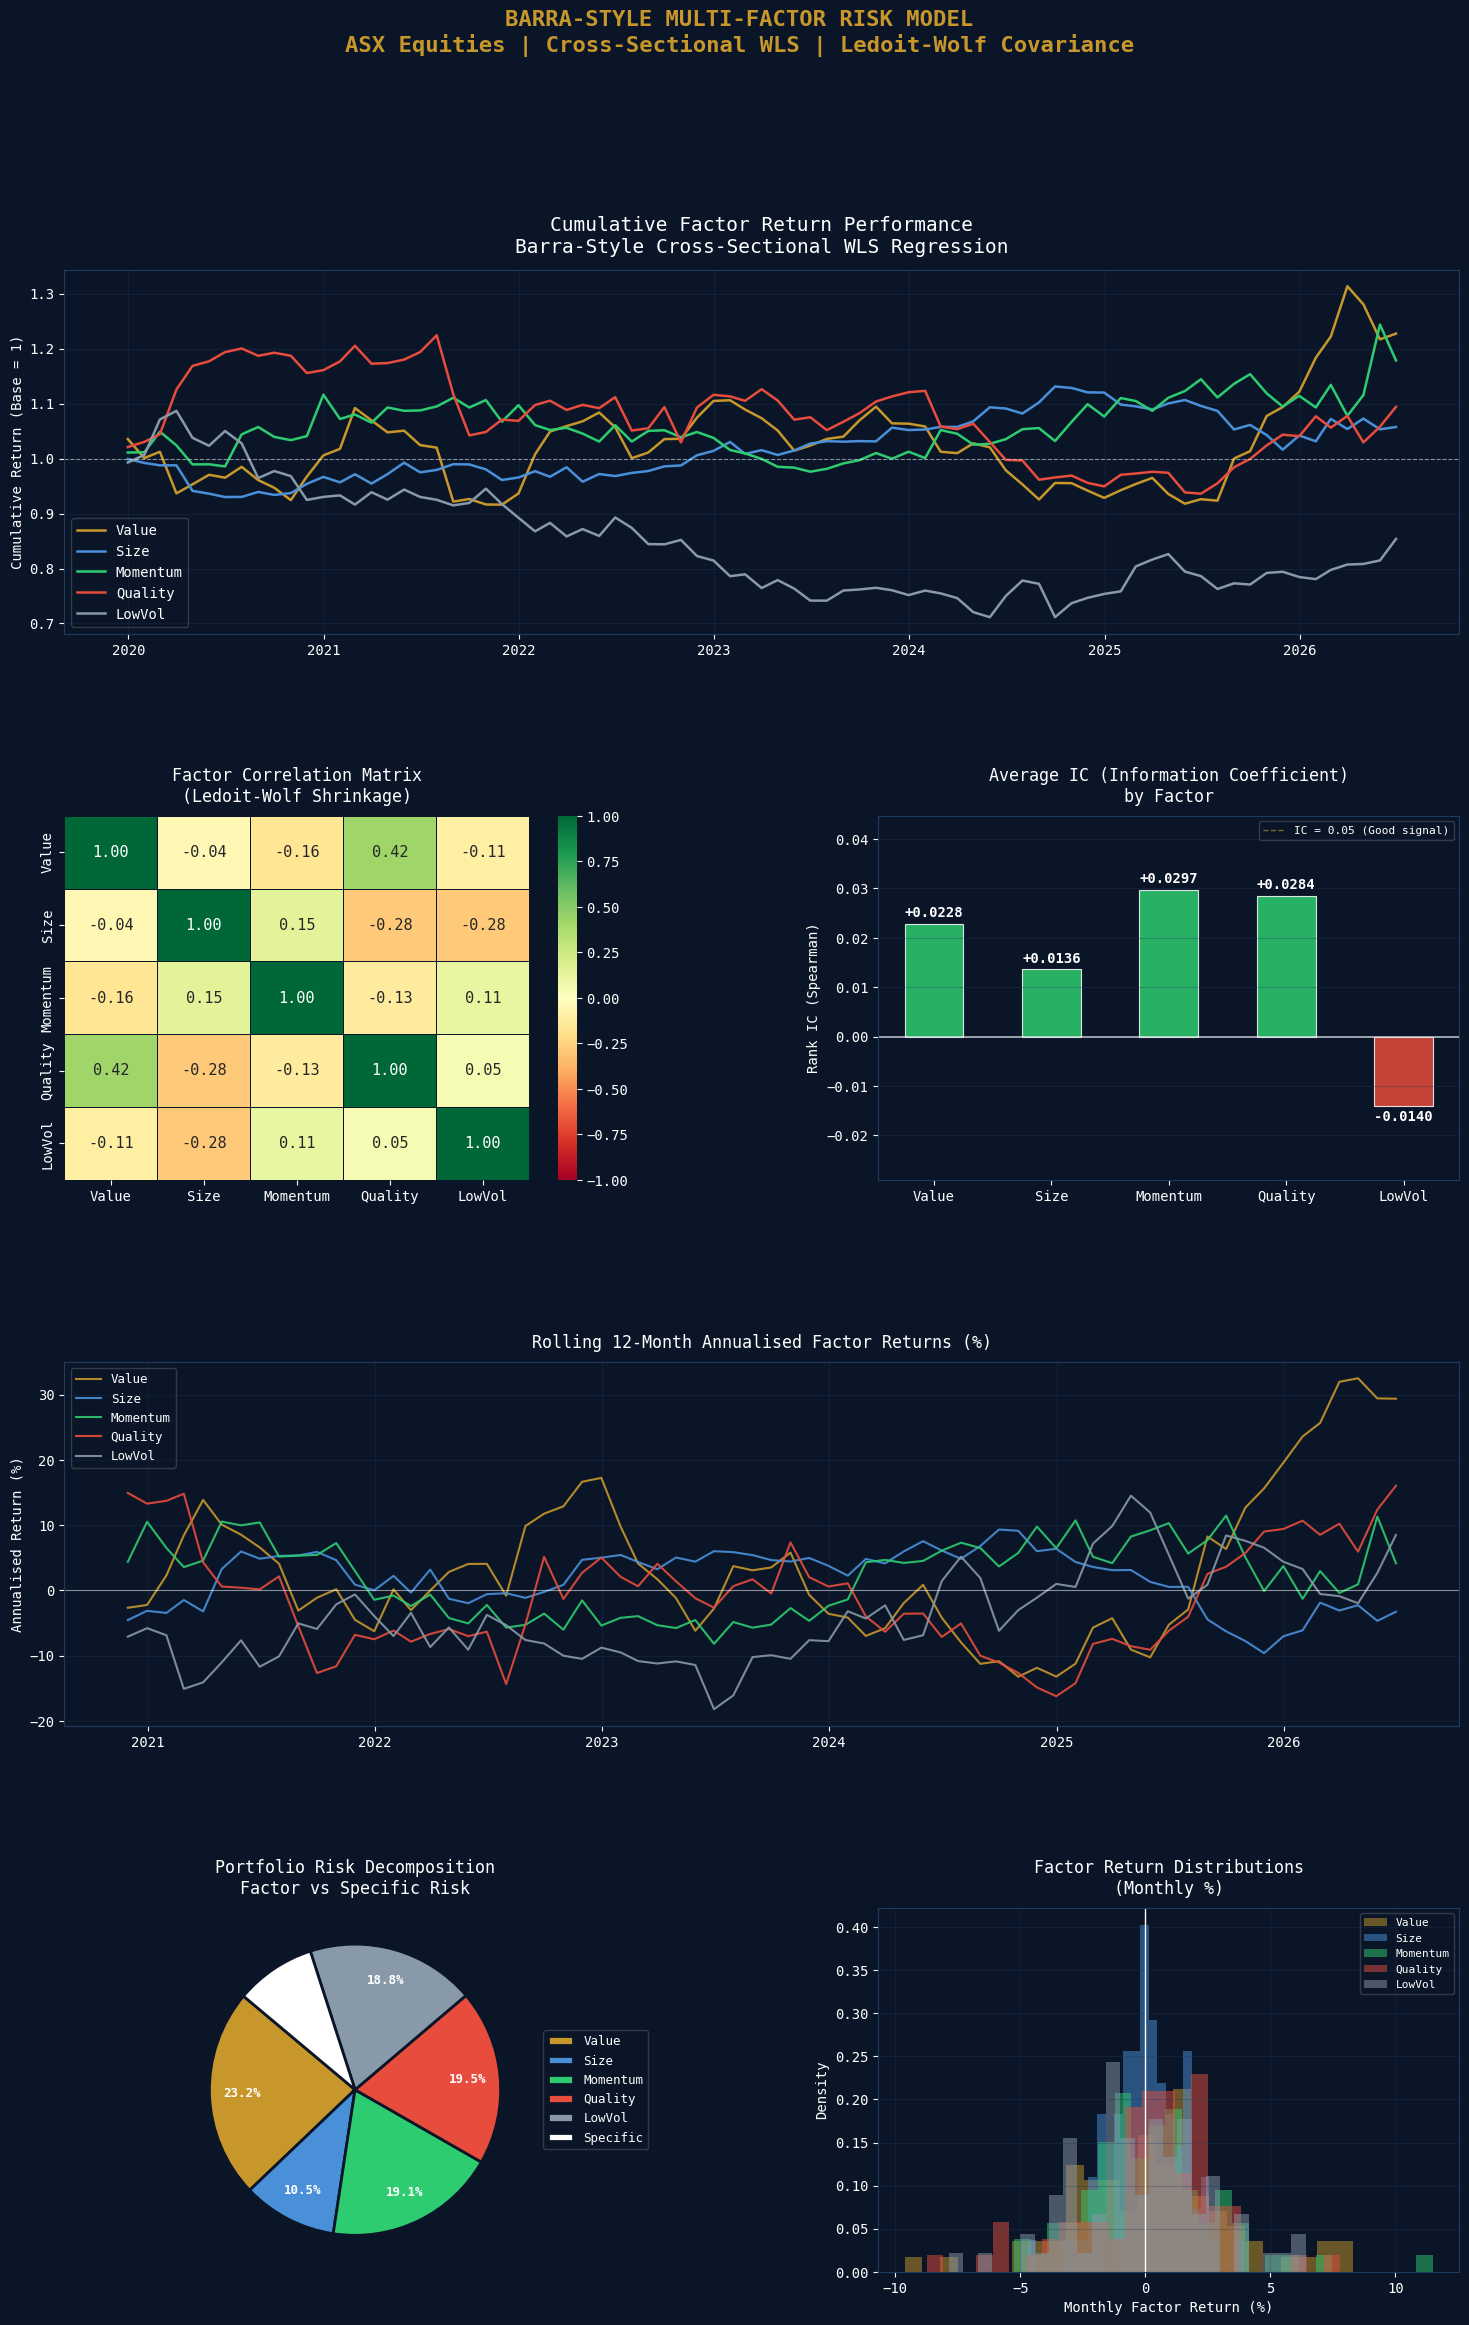

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Chart saved and downloaded!


In [26]:
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy import stats as spstats
from sklearn.covariance import LedoitWolf

GOLD  = '#C8972B'
BLUE  = '#4A90D9'
GREEN = '#2ECC71'
RED   = '#E74C3C'
WHITE = '#FFFFFF'
GREY  = '#8899AA'

factors  = factor_returns.columns.tolist()
colors_f = [GOLD, BLUE, GREEN, RED, GREY]

# Recompute IC values
ic_vals = []
for f in factors:
    ics = []
    for date in monthly_returns.index:
        if date not in factor_exposures:
            continue
        exp_d = factor_exposures[date]
        exps, rets = [], []
        for t, e in exp_d.items():
            if t in monthly_returns.columns:
                try:
                    r = float(monthly_returns.loc[date, t])
                    v = e.get(f, np.nan)
                    if not np.isnan(r) and v is not None and not np.isnan(float(v)):
                        exps.append(float(v))
                        rets.append(r)
                except Exception:
                    continue
        if len(exps) > 5:
            ic, _ = spstats.spearmanr(exps, rets)
            ics.append(ic)
    ic_vals.append(np.nanmean(ics) if ics else 0)

# Recompute factor correlation
factor_corr = factor_returns.corr()

# Risk decomposition values
factor_vols  = [factor_returns[f].std() * np.sqrt(12) * 100 for f in factors]
specific_vol = 4.33
factor_vols.append(specific_vol)
factor_names = factors + ['Specific']
total_v      = sum(factor_vols)
risk_pcts    = [v / total_v * 100 for v in factor_vols]
colors_pie   = [GOLD, BLUE, GREEN, RED, GREY, WHITE]

# ── Build Figure ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 26))
fig.patch.set_facecolor('#0A1628')
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.40)

# ── Chart 1: Cumulative Factor Returns ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
cum_factor_rets = (1 + factor_returns).cumprod()
for f, c in zip(factors, colors_f):
    ax1.plot(cum_factor_rets.index, cum_factor_rets[f].values,
             color=c, lw=1.8, label=f)
ax1.axhline(y=1, color=WHITE, lw=0.8, alpha=0.5, linestyle='--')
ax1.set_title('Cumulative Factor Return Performance\nBarra-Style Cross-Sectional WLS Regression',
              fontsize=14, color=WHITE, pad=12)
ax1.set_ylabel('Cumulative Return (Base = 1)', color=WHITE)
ax1.legend(fontsize=10, framealpha=0.2)
ax1.set_facecolor('#0A1628')
ax1.grid(True, alpha=0.3)

# ── Chart 2: Factor Correlation Heatmap ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(factor_corr, ax=ax2, cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#0A1628',
            annot_kws={'size': 11})
ax2.set_title('Factor Correlation Matrix\n(Ledoit-Wolf Shrinkage)',
              fontsize=12, color=WHITE, pad=10)
ax2.set_facecolor('#0A1628')

# ── Chart 3: IC Bar Chart (Fixed Labels) ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
colors_ic = [GREEN if ic > 0 else RED for ic in ic_vals]
bars = ax3.bar(factors, ic_vals, color=colors_ic, alpha=0.85,
               edgecolor='white', linewidth=0.8, width=0.5)
ax3.axhline(y=0, color=WHITE, lw=1.2, alpha=0.7)

# Place labels above positive bars, below negative bars
for bar, val in zip(bars, ic_vals):
    if val >= 0:
        ypos = val + 0.0008
        va   = 'bottom'
    else:
        ypos = val - 0.0008
        va   = 'top'
    ax3.text(bar.get_x() + bar.get_width() / 2,
             ypos, f'{val:+.4f}',
             ha='center', va=va,
             color=WHITE, fontsize=10, fontweight='bold')

ax3.axhline(y=0.05,  color=GOLD, lw=1.0, linestyle='--',
            alpha=0.6, label='IC = 0.05 (Good signal)')
ax3.axhline(y=-0.05, color=RED,  lw=1.0, linestyle='--', alpha=0.6)
ax3.set_ylim(min(ic_vals) - 0.015, max(ic_vals) + 0.015)
ax3.set_title('Average IC (Information Coefficient)\nby Factor',
              fontsize=12, color=WHITE, pad=10)
ax3.set_ylabel('Rank IC (Spearman)', color=WHITE)
ax3.legend(fontsize=8, framealpha=0.2)
ax3.set_facecolor('#0A1628')
ax3.grid(True, alpha=0.3, axis='y')

# ── Chart 4: Rolling 12-Month Factor Returns ─────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
rolling_12 = factor_returns.rolling(12).mean() * 12 * 100
for f, c in zip(factors, colors_f):
    ax4.plot(rolling_12.index, rolling_12[f].values,
             color=c, lw=1.5, label=f, alpha=0.9)
ax4.axhline(y=0, color=WHITE, lw=0.8, alpha=0.5)
ax4.set_title('Rolling 12-Month Annualised Factor Returns (%)',
              fontsize=12, color=WHITE, pad=10)
ax4.set_ylabel('Annualised Return (%)', color=WHITE)
ax4.legend(fontsize=9, framealpha=0.2)
ax4.set_facecolor('#0A1628')
ax4.grid(True, alpha=0.3)

# ── Chart 5: Portfolio Risk Decomposition (Clean Pie) ────────────────────────
ax5 = fig.add_subplot(gs[3, 0])
wedges, texts, autotexts = ax5.pie(
    risk_pcts,
    labels=None,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'edgecolor': '#0A1628', 'linewidth': 2},
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color(WHITE)
    at.set_fontweight('bold')
ax5.legend(
    wedges, factor_names,
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9,
    framealpha=0.2,
    labelcolor=WHITE
)
ax5.set_title('Portfolio Risk Decomposition\nFactor vs Specific Risk',
              fontsize=12, color=WHITE, pad=10)
ax5.set_facecolor('#0A1628')

# ── Chart 6: Factor Return Distributions ─────────────────────────────────────
ax6 = fig.add_subplot(gs[3, 1])
for f, c in zip(factors, colors_f):
    ax6.hist(factor_returns[f] * 100, bins=25, alpha=0.5,
             color=c, edgecolor='none', label=f, density=True)
ax6.axvline(x=0, color=WHITE, lw=1.0)
ax6.set_title('Factor Return Distributions\n(Monthly %)',
              fontsize=12, color=WHITE, pad=10)
ax6.set_xlabel('Monthly Factor Return (%)', color=WHITE)
ax6.set_ylabel('Density', color=WHITE)
ax6.legend(fontsize=8, framealpha=0.2)
ax6.set_facecolor('#0A1628')
ax6.grid(True, alpha=0.3)

fig.suptitle(
    'BARRA-STYLE MULTI-FACTOR RISK MODEL\nASX Equities | Cross-Sectional WLS | Ledoit-Wolf Covariance',
    fontsize=16, color=GOLD, y=0.98, fontweight='bold'
)

plt.savefig('asx_factor_risk_model.png', dpi=150,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()
files.download('asx_factor_risk_model.png')
print("Chart saved and downloaded!")

In [24]:
print("\n" + "=" * 65)
print("  BARRA-STYLE FACTOR RISK MODEL - SUMMARY REPORT")
print("=" * 65)

print(f"\n  FACTOR PERFORMANCE SUMMARY")
print(f"  {'Factor':<14} {'Avg Monthly':>12} {'Ann Return':>12} {'Ann Vol':>10} {'t-stat':>8}")
print(f"  {'-'*58}")
for f in factors:
    avg_m  = factor_returns[f].mean()
    ann_r  = (1 + avg_m)**12 - 1
    ann_v  = factor_returns[f].std() * np.sqrt(12)
    t_stat = avg_m / (factor_returns[f].std() / np.sqrt(len(factor_returns)))
    print(f"  {f:<14} {avg_m*100:>+11.3f}% {ann_r*100:>+11.1f}% {ann_v*100:>9.1f}% {t_stat:>8.2f}")

print(f"\n  FACTOR CORRELATIONS (Key Pairs)")
for i, f1 in enumerate(factors):
    for j, f2 in enumerate(factors):
        if j > i:
            print(f"  {f1} vs {f2}: {factor_corr.loc[f1,f2]:.3f}")

print(f"\n  PORTFOLIO RISK DECOMPOSITION")
print(f"  Factor Volatility  : {port_factor_vol:.2f}% annualised")
print(f"  Specific Volatility: {port_spec_vol*100:.2f}% annualised")
print(f"  Total Volatility   : {total_vol:.2f}% annualised")

print(f"\n  PORTFOLIO FACTOR EXPOSURES")
for f, exp in zip(factor_returns.columns, port_exp_vec):
    print(f"  {f:<14}: {exp:>+.4f}")

print(f"\n  INFORMATION COEFFICIENTS")
for f, ic in zip(factors, ic_vals):
    print(f"  {f:<14}: IC = {ic:>+.4f}")

print("\n" + "=" * 65)
print("  PROJECT 6 COMPLETE!")
print("  File saved: asx_factor_risk_model.png")
print("=" * 65)


  BARRA-STYLE FACTOR RISK MODEL - SUMMARY REPORT

  FACTOR PERFORMANCE SUMMARY
  Factor          Avg Monthly   Ann Return    Ann Vol   t-stat
  ----------------------------------------------------------
  Value               +0.312%        +3.8%      11.3%     0.85
  Size                +0.082%        +1.0%       5.1%     0.49
  Momentum            +0.243%        +3.0%       9.3%     0.81
  Quality             +0.151%        +1.8%       9.5%     0.49
  LowVol              -0.166%        -2.0%       9.1%    -0.56

  FACTOR CORRELATIONS (Key Pairs)
  Value vs Size: -0.044
  Value vs Momentum: -0.160
  Value vs Quality: 0.416
  Value vs LowVol: -0.105
  Size vs Momentum: 0.145
  Size vs Quality: -0.283
  Size vs LowVol: -0.282
  Momentum vs Quality: -0.131
  Momentum vs LowVol: 0.110
  Quality vs LowVol: 0.049

  PORTFOLIO RISK DECOMPOSITION
  Factor Volatility  : 167.41% annualised
  Specific Volatility: 4.74% annualised
  Total Volatility   : 167.41% annualised

  PORTFOLIO FACTOR EXPO